# 🎯 Análise da Mega-Sena (1996–2026)

## 📌 Objetivo
Este projeto tem como objetivo realizar uma análise exploratória (EDA) dos sorteios da Mega-Sena, buscando identificar padrões estatísticos, distribuições e comportamentos dos números sorteados ao longo do tempo.

## 🧠 Perguntas que queremos responder:
- Existe padrão na frequência das dezenas?
- A soma dos números segue distribuição normal?
- Há equilíbrio entre números pares e ímpares?
- Existem dezenas "atrasadas"?
- Como os sorteios se comportam ao longo dos anos?

## 🛠 Ferramentas utilizadas:
- Python
- Pandas
- Matplotlib / Seaborn
- Jupyter Notebook

🟩 2. Importação das bibliotecas

In [1]:
# ------------------------------------------------------------
# IMPORTAÇÃO DE BIBLIOTECAS
# ------------------------------------------------------------

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão
plt.style.use("default")
sns.set_theme()

🟩 3. Carregamento dos dados

In [2]:
# ------------------------------------------------------------
# LEITURA DO ARQUIVO
# ------------------------------------------------------------

# Caminho do arquivo Excel
caminho = "Mega_Sena.xlsx"

# Leitura do arquivo
df = pd.read_excel(caminho)

# Visualizar primeiras linhas
df.head()

,Concurso,Data do Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6,Ganhadores 6 acertos,Cidade / UF,Rateio 6 acertos,Ganhadores 5 acertos,Rateio 5 acertos,Ganhadores 4 acertos,Rateio 4 acertos,Acumulado 6 acertos,Arrecadação Total,Estimativa prêmio,Acumulado Sorteio Especial Mega da Virada,Observação
0,1,11/03/1996,4,5,30,33,41,52,0,NaN,"R$0,00",17,"R$39.158,92",2016,"R$330,21","R$1.714.650,23","R$0,00","R$0,00","R$0,00",NaN
1,2,18/03/1996,9,37,39,41,43,49,1,PR,"R$2.307.162,23",65,"R$14.424,02",4488,"R$208,91","R$0,00","R$0,00","R$0,00","R$0,00",NaN
2,3,25/03/1996,10,11,29,30,36,47,2,RN; SP,"R$391.192,51",62,"R$10.515,93",4261,"R$153,01","R$0,00","R$0,00","R$0,00","R$0,00",NaN
3,4,01/04/1996,1,5,6,27,42,59,0,NaN,"R$0,00",39,"R$15.322,24",3311,"R$180,48","R$717.080,75","R$0,00","R$0,00","R$0,00",NaN
4,5,08/04/1996,1,2,6,16,19,46,0,NaN,"R$0,00",98,"R$5.318,10",5399,"R$96,53","R$1.342.488,85","R$0,00","R$0,00","R$0,00",NaN


In [ ]:
# ------------------------------------------------------------
# PADRONIZAÇÃO AVANÇADA DAS COLUNAS
# ------------------------------------------------------------

import unicodedata

def limpar_nome_coluna(col):
    # Remove acentos
    col = unicodedata.normalize('NFKD', col).encode('ASCII', 'ignore').decode('ASCII')
    
    # Minúsculo
    col = col.lower()
    
    # Substituições
    col = col.replace(" ", "_").replace("/", "_")
    
    # Remove múltiplos underscores
    while "__" in col:
        col = col.replace("__", "_")
    
    return col.strip("_")

# Aplicar
df.columns = [limpar_nome_coluna(col) for col in df.columns]

# Conferir
df.columns

🟩 4. Limpeza e tratamento de dados

In [3]:
# ------------------------------------------------------------
# ETAPA 2: Padronizar nomes das colunas
# ------------------------------------------------------------
# Isso facilita muito no uso das colunas no código
df.columns = (
    df.columns
    .str.lower()            # Converte tudo para minúsculas
    .str.strip()            # Remove espaços extras
    .str.replace(" ", "_")  # Troca espaços por underline
    .str.replace("/", "_")  # Troca barras por underline
)

df.head()

,concurso,data_do_sorteio,bola1,bola2,bola3,bola4,bola5,bola6,ganhadores_6_acertos,cidade___uf,rateio_6_acertos,ganhadores_5_acertos,rateio_5_acertos,ganhadores_4_acertos,rateio_4_acertos,acumulado_6_acertos,arrecadação_total,estimativa_prêmio,acumulado_sorteio_especial_mega_da_virada,observação
0,1,11/03/1996,4,5,30,33,41,52,0,NaN,"R$0,00",17,"R$39.158,92",2016,"R$330,21","R$1.714.650,23","R$0,00","R$0,00","R$0,00",NaN
1,2,18/03/1996,9,37,39,41,43,49,1,PR,"R$2.307.162,23",65,"R$14.424,02",4488,"R$208,91","R$0,00","R$0,00","R$0,00","R$0,00",NaN
2,3,25/03/1996,10,11,29,30,36,47,2,RN; SP,"R$391.192,51",62,"R$10.515,93",4261,"R$153,01","R$0,00","R$0,00","R$0,00","R$0,00",NaN
3,4,01/04/1996,1,5,6,27,42,59,0,NaN,"R$0,00",39,"R$15.322,24",3311,"R$180,48","R$717.080,75","R$0,00","R$0,00","R$0,00",NaN
4,5,08/04/1996,1,2,6,16,19,46,0,NaN,"R$0,00",98,"R$5.318,10",5399,"R$96,53","R$1.342.488,85","R$0,00","R$0,00","R$0,00",NaN


In [ ]:
# ------------------------------------------------------------
# LIMPEZA E TRATAMENTO
# ------------------------------------------------------------

# Converter data para datetime
df["data_do_sorteio"] = pd.to_datetime(
    df["data_do_sorteio"],
    dayfirst=True,
    errors="coerce"  # se tiver algo inválido vira NaT
)

In [6]:
df["data_do_sorteio"].head()
df["data_do_sorteio"].isna().sum()

np.int64(0)

In [7]:
df.columns

Index(['concurso', 'data_do_sorteio', 'bola1', 'bola2', 'bola3', 'bola4',
       'bola5', 'bola6', 'ganhadores_6_acertos', 'cidade___uf',
       'rateio_6_acertos', 'ganhadores_5_acertos', 'rateio_5_acertos',
       'ganhadores_4_acertos', 'rateio_4_acertos', 'acumulado_6_acertos',
       'arrecadação_total', 'estimativa_prêmio',
       'acumulado_sorteio_especial_mega_da_virada', 'observação'],
      dtype='object')

In [15]:
# ------------------------------------------------------------
# Criar colunas auxiliares de data
# ------------------------------------------------------------
df["ano"] = df["data_do_sorteio"].dt.year
df["mes"] = df["data_do_sorteio"].dt.month
df["dia"] = df["data_do_sorteio"].dt.day

🟩 5. Engenharia de atributos

In [17]:
# ------------------------------------------------------------
# ENGENHARIA DE ATRIBUTOS
# ------------------------------------------------------------

# Lista com as dezenas
colunas_bolas = ["bola1","bola2","bola3","bola4","bola5","bola6"]

# Soma das dezenas
df["soma_dezenas"] = df[colunas_bolas].sum(axis=1)

# Média
df["media_dezenas"] = df["soma_dezenas"] / 6

# Pares
df["qtd_pares"] = df[colunas_bolas].apply(lambda x: (x % 2 == 0).sum(), axis=1)

# Ímpares
df["qtd_impares"] = 6 - df["qtd_pares"]

# Range (máximo - mínimo)
df["range"] = df[colunas_bolas].max(axis=1) - df[colunas_bolas].min(axis=1)

🟩 6. Análise exploratória (EDA)

📊 Frequência das dezenas

In [18]:
# ------------------------------------------------------------
# FREQUÊNCIA DAS DEZENAS
# ------------------------------------------------------------

todas = df[colunas_bolas].values.flatten()

freq = pd.Series(todas).value_counts().sort_index()

freq.head()

1    294
2    297
3    279
4    316
5    324
Name: count, dtype: int64

📊 Gráfico de frequência

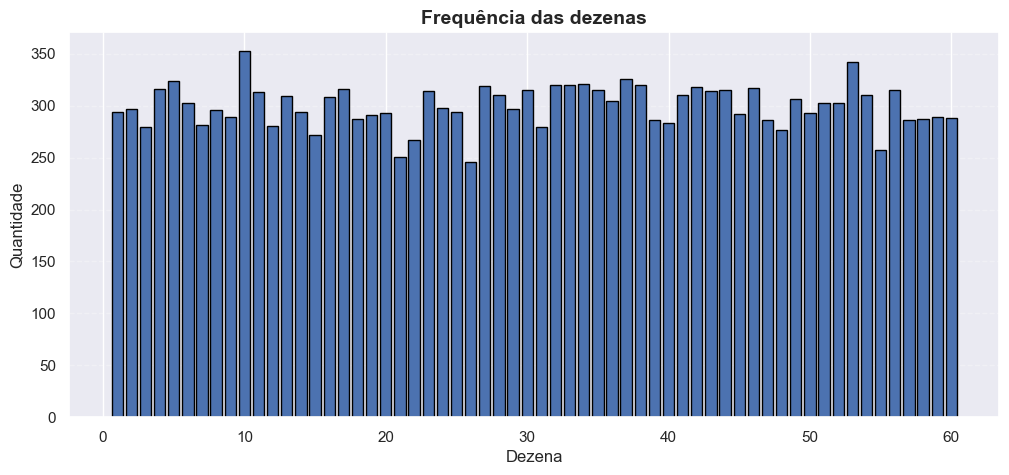

In [28]:
plt.figure(figsize=(12,5))
plt.bar(freq.index, freq.values, edgecolor="black")
plt.title("Frequência das dezenas", fontsize=14, weight="bold")
plt.xlabel("Dezena")
plt.ylabel("Quantidade")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

### 🔥 Top 10 dezenas mais frequentes

In [30]:
# Top 10 dezenas mais sorteadas
top10 = freq.sort_values(ascending=False).head(10)
top10

10    353
53    342
37    326
5     324
34    321
33    320
32    320
38    320
27    319
42    318
Name: count, dtype: int64

📊 Histograma da soma

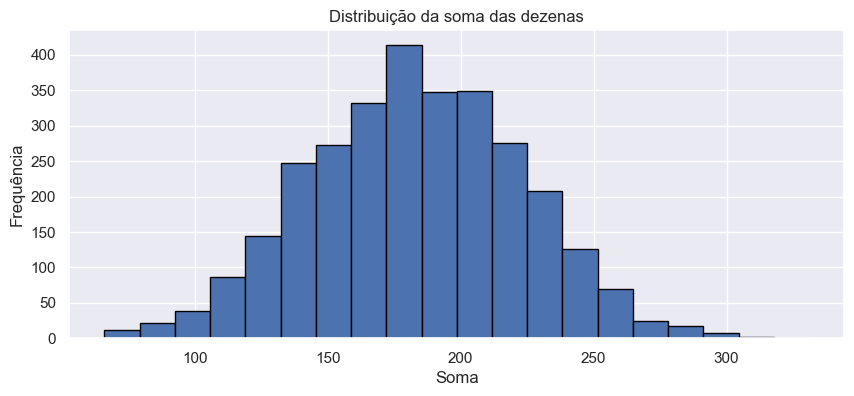

In [20]:
plt.figure(figsize=(10,4))
plt.hist(df["soma_dezenas"], bins=20, edgecolor="black")
plt.title("Distribuição da soma das dezenas")
plt.xlabel("Soma")
plt.ylabel("Frequência")
plt.show()

📊 Histograma do range

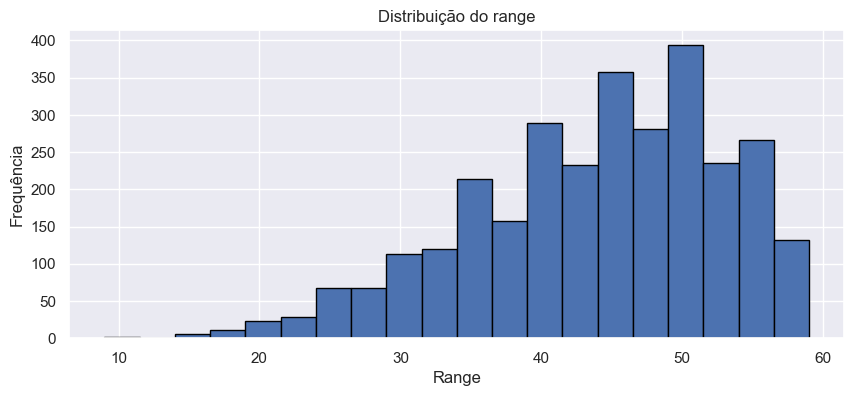

In [21]:
plt.figure(figsize=(10,4))
plt.hist(df["range"], bins=20, edgecolor="black")
plt.title("Distribuição do range")
plt.xlabel("Range")
plt.ylabel("Frequência")
plt.show()

📊 Heatmap de sorteios

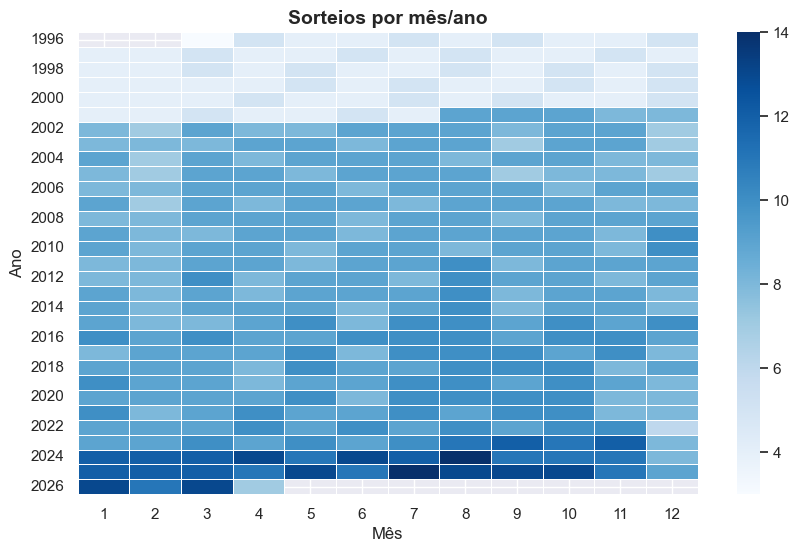

In [29]:
df[["ano", "mes"]].head()

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="Blues", linewidths=0.5)
plt.title("Sorteios por mês/ano", fontsize=14, weight="bold")
plt.xlabel("Mês")
plt.ylabel("Ano")
plt.show()

🟩 7. Teste de normalidade

In [24]:
# ------------------------------------------------------------
# FUNÇÃO: teste_normalidade
# ------------------------------------------------------------
# Objetivo:
# Realizar análise completa de normalidade em uma variável:
# - Histograma + KDE + curva normal
# - Testes estatísticos (Shapiro e Kolmogorov-Smirnov)
# - Gráfico Q-Q
# ------------------------------------------------------------

def teste_normalidade(serie, nome_variavel="Variável"):
    
    # --------------------------------------------------------
    # Importações necessárias (dentro da função para garantir)
    # --------------------------------------------------------
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import norm, shapiro, kstest
    import scipy.stats as stats

    # --------------------------------------------------------
    # Preparação dos dados
    # --------------------------------------------------------
    
    # Remover valores nulos (boa prática)
    dados = serie.dropna()

    # Calcular média e desvio padrão
    media = dados.mean()
    desvio = dados.std()

    print(f"\n📊 Análise de Normalidade: {nome_variavel}")
    print("-" * 50)
    print(f"Média: {media:.2f}")
    print(f"Desvio padrão: {desvio:.2f}")
    print(f"Tamanho da amostra: {len(dados)}")

    # --------------------------------------------------------
    # 1. HISTOGRAMA + KDE + CURVA NORMAL
    # --------------------------------------------------------
    
    # Criar eixo X para curva normal
    x = np.linspace(dados.min(), dados.max(), 1000)
    y = norm.pdf(x, media, desvio)

    plt.figure(figsize=(12,5))

    # Histograma + KDE
    sns.histplot(
        dados,
        bins=30,
        kde=True,
        stat="density",
        color="#4A90E2",
        edgecolor="black",
        alpha=0.6
    )

    # Curva normal teórica
    plt.plot(x, y, color="red", linewidth=2, label="Normal Teórica")

    plt.title(f"Distribuição de {nome_variavel} vs Normal", weight="bold")
    plt.xlabel(nome_variavel)
    plt.ylabel("Densidade")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.show()

    # --------------------------------------------------------
    # 2. TESTES DE NORMALIDADE
    # --------------------------------------------------------

    # Shapiro-Wilk (bom para até ~5000 amostras)
    stat_shapiro, p_shapiro = shapiro(dados)

    # Kolmogorov-Smirnov
    stat_ks, p_ks = kstest(
        dados,
        'norm',
        args=(media, desvio)
    )

    print("\n🧪 Testes Estatísticos:")
    print("-" * 30)

    print(f"Shapiro-Wilk -> Estatística: {stat_shapiro:.4f} | p-valor: {p_shapiro:.4f}")
    print(f"Kolmogorov-Smirnov -> Estatística: {stat_ks:.4f} | p-valor: {p_ks:.4f}")

    # Interpretação automática
    print("\n📌 Interpretação:")
    
    if p_shapiro > 0.05:
        print("✔ Shapiro: distribuição pode ser normal")
    else:
        print("❌ Shapiro: distribuição NÃO é normal")

    if p_ks > 0.05:
        print("✔ KS: distribuição pode ser normal")
    else:
        print("❌ KS: distribuição NÃO é normal")

    # --------------------------------------------------------
    # 3. GRÁFICO Q-Q
    # --------------------------------------------------------

    plt.figure(figsize=(6,6))

    stats.probplot(dados, dist="norm", plot=plt)

    plt.title(f"Q-Q Plot - {nome_variavel}")
    plt.grid(alpha=0.3)

    plt.show()

    print("\n" + "="*60)


📊 Análise de Normalidade: Soma das Dezenas
--------------------------------------------------
Média: 183.15
Desvio padrão: 39.95
Tamanho da amostra: 2998


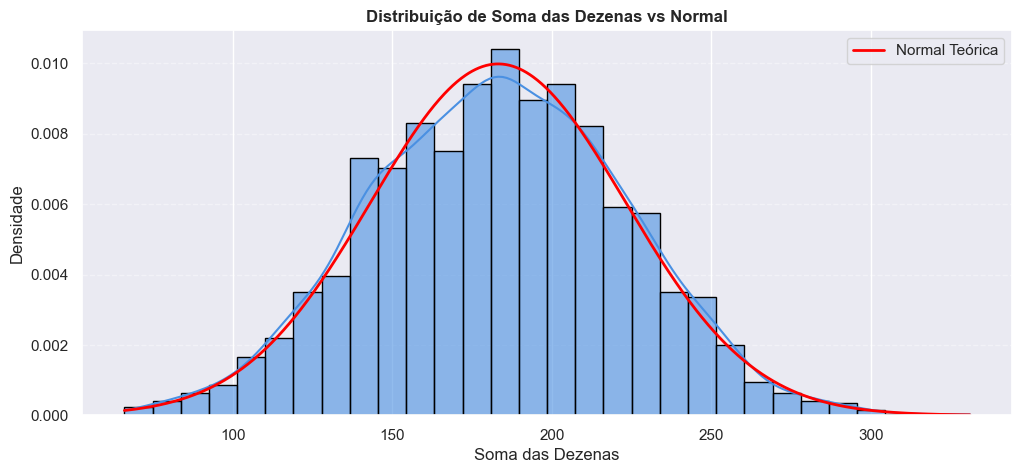


🧪 Testes Estatísticos:
------------------------------
Shapiro-Wilk -> Estatística: 0.9991 | p-valor: 0.1312
Kolmogorov-Smirnov -> Estatística: 0.0180 | p-valor: 0.2808

📌 Interpretação:
✔ Shapiro: distribuição pode ser normal
✔ KS: distribuição pode ser normal


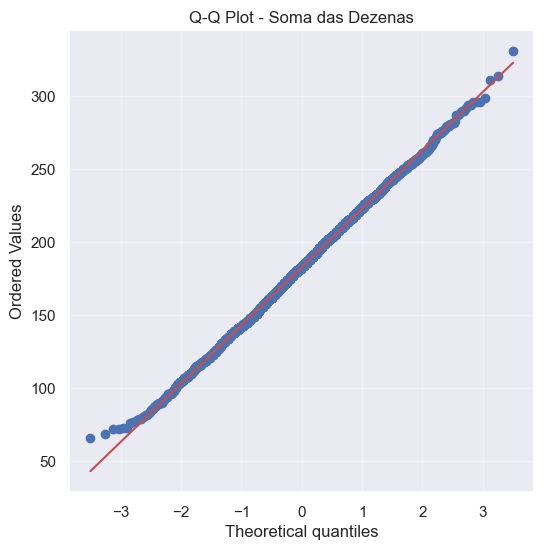

In [25]:
# Usando a função que criamos
teste_normalidade(df["soma_dezenas"], "Soma das Dezenas")

🟩 8. Insights encontrados (Markdown)

## 📌 Principais Insights

- A soma das dezenas apresenta comportamento próximo de uma distribuição normal
- A combinação mais comum é 3 pares e 3 ímpares
- Algumas dezenas aparecem com maior frequência ao longo do tempo
- O range dos sorteios tende a se concentrar entre 40 e 50
- Existem dezenas com longos períodos sem serem sorteadas

🟩 9. Conclusão final

## 🧠 Conclusão

A análise mostrou que, embora os sorteios da Mega-Sena sejam aleatórios, existem padrões estatísticos observáveis ao longo do tempo.

Esses padrões não permitem prever resultados futuros com precisão, mas ajudam a entender o comportamento histórico dos sorteios.

Este projeto demonstra técnicas de:
- Análise exploratória de dados (EDA)
- Engenharia de atributos
- Visualização de dados
- Testes estatísticos


In [31]:
df.to_csv("mega_sena_tratado2.csv", index=False)